In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
dataset = pd.read_csv("clv_dataset.csv")
dataset.head()

,customer_id,age,gender,city,region,tenure_months,recency_days,frequency_orders,total_spent,avg_order_value,...,email_click_rate,loyalty_points,customer_segment,complaints,satisfaction_score,churn_risk,referral_count,avg_session_time,last_login_days,future_clv
0,1,45,Male,Bangalore,North,34,130,11,22049.35,1939.69,...,0.177,1077,Budget,0,4.7,0.126,1,16.91,116,48482.24
1,2,55,Female,Hyderabad,East,29,115,12,9864.60,930.01,...,0.081,694,Budget,0,3.1,0.178,4,11.15,57,36361.03
2,3,61,Male,Pune,South,11,195,15,27296.93,1546.24,...,0.184,999,Regular,0,3.6,0.231,1,25.61,116,46998.61
3,4,43,Female,Mumbai,Central,32,40,11,14348.10,1493.76,...,0.340,254,Budget,0,1.6,0.156,2,17.64,77,44372.90
4,5,60,Male,Mumbai,West,14,17,13,14451.23,1246.99,...,0.555,332,Budget,0,3.5,0.000,0,14.54,14,48491.85


In [4]:
dataset.shape

(100000, 28)

In [6]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   customer_id           100000 non-null  int64  
 1   age                   100000 non-null  int64  
 2   gender                100000 non-null  object 
 3   city                  100000 non-null  object 
 4   region                100000 non-null  object 
 5   tenure_months         100000 non-null  int64  
 6   recency_days          100000 non-null  int64  
 7   frequency_orders      100000 non-null  int64  
 8   total_spent           100000 non-null  float64
 9   avg_order_value       100000 non-null  float64
 10  max_order_value       100000 non-null  float64
 11  min_order_value       100000 non-null  float64
 12  last_purchase_value   100000 non-null  float64
 13  product_category      100000 non-null  object 
 14  discount_usage        100000 non-null  int64  
 15  r

In [7]:
dataset.tail()

,customer_id,age,gender,city,region,tenure_months,recency_days,frequency_orders,total_spent,avg_order_value,...,email_click_rate,loyalty_points,customer_segment,complaints,satisfaction_score,churn_risk,referral_count,avg_session_time,last_login_days,future_clv
99995,99996,27,Male,Ahmedabad,South,29,286,19,44771.82,2540.46,...,0.192,1540,Premium,0,4.5,0.193,4,27.13,69,80320.18
99996,99997,45,Male,Mumbai,East,71,4,16,22185.46,1508.96,...,0.148,1100,Budget,1,4.5,0.174,4,12.01,9,64352.84
99997,99998,51,Male,Pune,West,45,28,14,20886.34,1708.75,...,0.113,719,Budget,0,3.1,0.187,4,22.46,84,68909.29
99998,99999,64,Female,Bangalore,East,33,126,25,6651.73,283.90,...,0.153,0,Budget,0,3.1,0.210,6,8.72,84,38468.95
99999,100000,45,Male,Kolkata,West,43,75,21,34997.84,1877.71,...,0.120,1118,Regular,0,3.8,0.039,3,18.00,90,60816.20


In [10]:
dataset.describe()

,customer_id,age,tenure_months,recency_days,frequency_orders,total_spent,avg_order_value,max_order_value,min_order_value,last_purchase_value,...,app_visits_per_month,email_click_rate,loyalty_points,complaints,satisfaction_score,churn_risk,referral_count,avg_session_time,last_login_days,future_clv
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,43.50998,35.904460,183.196570,19.010120,35172.673062,1806.049640,3789.435794,588.595185,2167.602021,...,12.999370,0.249744,1407.495730,0.700140,3.702149,0.290389,2.002530,18.049281,60.050980,62607.438925
std,28867.657797,14.95293,20.510644,105.209301,4.244669,15548.583997,645.267242,1681.677900,326.533197,1022.004989,...,3.453017,0.144285,666.757063,0.835722,0.728844,0.162154,1.411334,7.856924,34.344343,25802.784238
min,1.000000,18.00000,1.000000,1.000000,4.000000,1604.760000,200.000000,240.300000,20.190000,121.030000,...,2.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1000.000000
25%,25000.750000,31.00000,18.000000,92.000000,16.000000,24149.147500,1368.610000,2570.415000,330.205000,1408.270000,...,11.000000,0.138000,938.000000,0.000000,3.200000,0.167000,1.000000,12.630000,30.000000,44184.330000
50%,50000.500000,43.00000,36.000000,183.000000,19.000000,33540.645000,1803.370000,3593.735000,534.935000,2027.580000,...,13.000000,0.228000,1353.000000,1.000000,3.700000,0.288000,2.000000,18.000000,60.000000,61182.060000
75%,75000.250000,56.00000,54.000000,275.000000,22.000000,44457.122500,2242.550000,4834.722500,797.902500,2802.280000,...,15.000000,0.340000,1815.000000,1.000000,4.200000,0.409000,3.000000,23.350000,90.000000,79782.720000
max,100000.000000,69.00000,71.000000,365.000000,41.000000,136288.130000,4556.030000,13205.950000,2320.190000,7385.140000,...,31.000000,0.911000,5502.000000,8.000000,5.000000,1.000000,10.000000,51.190000,119.000000,177536.410000


In [13]:
dataset.mean(numeric_only = True)

customer_id             50000.500000
age                        43.509980
tenure_months              35.904460
recency_days              183.196570
frequency_orders           19.010120
total_spent             35172.673062
avg_order_value          1806.049640
max_order_value          3789.435794
min_order_value           588.595185
last_purchase_value      2167.602021
discount_usage              4.999830
returns_count               1.197640
app_visits_per_month       12.999370
email_click_rate            0.249744
loyalty_points           1407.495730
complaints                  0.700140
satisfaction_score          3.702149
churn_risk                  0.290389
referral_count              2.002530
avg_session_time           18.049281
last_login_days            60.050980
future_clv              62607.438925
dtype: float64

In [15]:
dataset.median(numeric_only = True)

customer_id             50000.500
age                        43.000
tenure_months              36.000
recency_days              183.000
frequency_orders           19.000
total_spent             33540.645
avg_order_value          1803.370
max_order_value          3593.735
min_order_value           534.935
last_purchase_value      2027.580
discount_usage              5.000
returns_count               1.000
app_visits_per_month       13.000
email_click_rate            0.228
loyalty_points           1353.000
complaints                  1.000
satisfaction_score          3.700
churn_risk                  0.288
referral_count              2.000
avg_session_time           18.000
last_login_days            60.000
future_clv              61182.060
dtype: float64

In [16]:
dataset.mode()

,customer_id,age,gender,city,region,tenure_months,recency_days,frequency_orders,total_spent,avg_order_value,...,email_click_rate,loyalty_points,customer_segment,complaints,satisfaction_score,churn_risk,referral_count,avg_session_time,last_login_days,future_clv
0,1,55.0,Male,Delhi,Central,19.0,62.0,18.0,30258.56,200.0,...,0.156,0.0,Budget,0.0,3.8,0.0,2.0,1.0,68.0,1000.0
1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37244.63,NaN,...,0.171,NaN,Regular,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,43592.96,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
99996,99997,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
99997,99998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
99998,99999,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
dataset.std(numeric_only=True)

customer_id             28867.657797
age                        14.952930
tenure_months              20.510644
recency_days              105.209301
frequency_orders            4.244669
total_spent             15548.583997
avg_order_value           645.267242
max_order_value          1681.677900
min_order_value           326.533197
last_purchase_value      1022.004989
discount_usage              2.237029
returns_count               1.097957
app_visits_per_month        3.453017
email_click_rate            0.144285
loyalty_points            666.757063
complaints                  0.835722
satisfaction_score          0.728844
churn_risk                  0.162154
referral_count              1.411334
avg_session_time            7.856924
last_login_days            34.344343
future_clv              25802.784238
dtype: float64

In [22]:
dataset.var(numeric_only=True)

customer_id             8.333417e+08
age                     2.235901e+02
tenure_months           4.206865e+02
recency_days            1.106900e+04
frequency_orders        1.801722e+01
total_spent             2.417585e+08
avg_order_value         4.163698e+05
max_order_value         2.828041e+06
min_order_value         1.066239e+05
last_purchase_value     1.044494e+06
discount_usage          5.004300e+00
returns_count           1.205510e+00
app_visits_per_month    1.192333e+01
email_click_rate        2.081818e-02
loyalty_points          4.445650e+05
complaints              6.984310e-01
satisfaction_score      5.312142e-01
churn_risk              2.629379e-02
referral_count          1.991864e+00
avg_session_time        6.173126e+01
last_login_days         1.179534e+03
future_clv              6.657837e+08
dtype: float64

In [24]:
dataset.skew(numeric_only=True)

customer_id            -1.064188e-16
age                    -1.068823e-03
tenure_months           5.539872e-03
recency_days            2.882385e-04
frequency_orders        2.401049e-01
total_spent             6.630717e-01
avg_order_value         4.815916e-02
max_order_value         5.706395e-01
min_order_value         7.278488e-01
last_purchase_value     6.446729e-01
discount_usage          4.436780e-01
returns_count           9.230834e-01
app_visits_per_month    2.863969e-01
email_click_rate        7.006092e-01
loyalty_points          5.456528e-01
complaints              1.199655e+00
satisfaction_score     -2.189788e-01
churn_risk              1.453685e-01
referral_count          6.878986e-01
avg_session_time        9.613881e-02
last_login_days         1.886953e-03
future_clv              2.605473e-01
dtype: float64

In [25]:
dataset.kurtosis(numeric_only=True)

customer_id            -1.200000
age                    -1.193435
tenure_months          -1.201579
recency_days           -1.198470
frequency_orders        0.069020
total_spent             0.771011
avg_order_value        -0.106286
max_order_value         0.242044
min_order_value         0.166776
last_purchase_value     0.262820
discount_usage          0.181777
returns_count           0.849021
app_visits_per_month    0.080088
email_click_rate        0.132389
loyalty_points          0.556000
complaints              1.481348
satisfaction_score     -0.333095
churn_risk             -0.611418
referral_count          0.423649
avg_session_time       -0.215418
last_login_days        -1.199952
future_clv             -0.193217
dtype: float64

In [27]:
dataset.corr(numeric_only=True)

,customer_id,age,tenure_months,recency_days,frequency_orders,total_spent,avg_order_value,max_order_value,min_order_value,last_purchase_value,...,app_visits_per_month,email_click_rate,loyalty_points,complaints,satisfaction_score,churn_risk,referral_count,avg_session_time,last_login_days,future_clv
customer_id,1.000000,0.001261,-0.000737,0.000074,0.000944,-0.002600,-0.001779,0.000002,-0.000406,0.004613,...,0.000112,0.003408,-0.003234,-0.002709,-0.001638,-0.001224,0.006813,0.001042,0.005222,-0.002365
age,0.001261,1.000000,0.001309,0.003130,0.001663,-0.000619,-0.001873,-0.000626,0.002318,-0.002592,...,-0.000394,-0.002194,-0.000102,0.000409,-0.001840,-0.000781,-0.003615,-0.000654,-0.000830,-0.001077
tenure_months,-0.000737,0.001309,1.000000,-0.001303,0.000053,-0.001015,-0.000200,0.000550,-0.001987,-0.000758,...,-0.006977,-0.003084,-0.002079,0.000826,0.007379,-0.002348,-0.001359,-0.000429,0.001566,0.143560
recency_days,0.000074,0.003130,-0.001303,1.000000,-0.000687,-0.004408,-0.004938,-0.001804,-0.001725,-0.003484,...,0.001424,0.005395,-0.001250,0.004190,-0.003178,0.787593,0.003120,-0.007187,-0.001955,-0.376952
frequency_orders,0.000944,0.001663,0.000053,-0.000687,1.000000,0.503122,-0.003686,-0.000518,-0.001514,-0.000277,...,0.005423,0.003365,0.465502,-0.002161,-0.000814,-0.002076,0.001857,-0.001977,0.000114,0.430375
total_spent,-0.002600,-0.000619,-0.001015,-0.004408,0.503122,1.000000,0.807843,0.652033,0.522844,0.615624,...,0.001111,0.005016,0.927566,0.000453,0.002724,-0.001651,-0.002834,0.001820,-0.003453,0.796025
avg_order_value,-0.001779,-0.001873,-0.000200,-0.004938,-0.003686,0.807843,1.000000,0.805572,0.646886,0.760782,...,-0.001519,0.003706,0.749103,0.002292,0.003724,-0.000525,-0.004666,0.004370,-0.003894,0.636300
max_order_value,0.000002,-0.000626,0.000550,-0.001804,-0.000518,0.652033,0.805572,1.000000,0.525421,0.615901,...,0.001279,0.005480,0.603985,-0.001333,0.001115,0.000529,-0.003167,0.003146,-0.002519,0.513537
min_order_value,-0.000406,0.002318,-0.001987,-0.001725,-0.001514,0.522844,0.646886,0.525421,1.000000,0.490646,...,0.001686,0.002132,0.484481,-0.000318,0.003250,-0.001481,-0.004949,0.002080,-0.001191,0.412686
last_purchase_value,0.004613,-0.002592,-0.000758,-0.003484,-0.000277,0.615624,0.760782,0.615901,0.490646,1.000000,...,-0.005008,0.003241,0.570958,0.003357,0.002700,0.001263,-0.008818,0.003537,-0.003938,0.485312


In [32]:
numeric_col = dataset.select_dtypes(exclude=["object"]).columns
catag_col = dataset.select_dtypes(include=["object"]).columns

In [34]:
numeric_col

Index(['customer_id', 'age', 'tenure_months', 'recency_days',
       'frequency_orders', 'total_spent', 'avg_order_value', 'max_order_value',
       'min_order_value', 'last_purchase_value', 'discount_usage',
       'returns_count', 'app_visits_per_month', 'email_click_rate',
       'loyalty_points', 'complaints', 'satisfaction_score', 'churn_risk',
       'referral_count', 'avg_session_time', 'last_login_days', 'future_clv'],
      dtype='object')

In [35]:
catag_col

Index(['gender', 'city', 'region', 'product_category', 'payment_method',
       'customer_segment'],
      dtype='object')

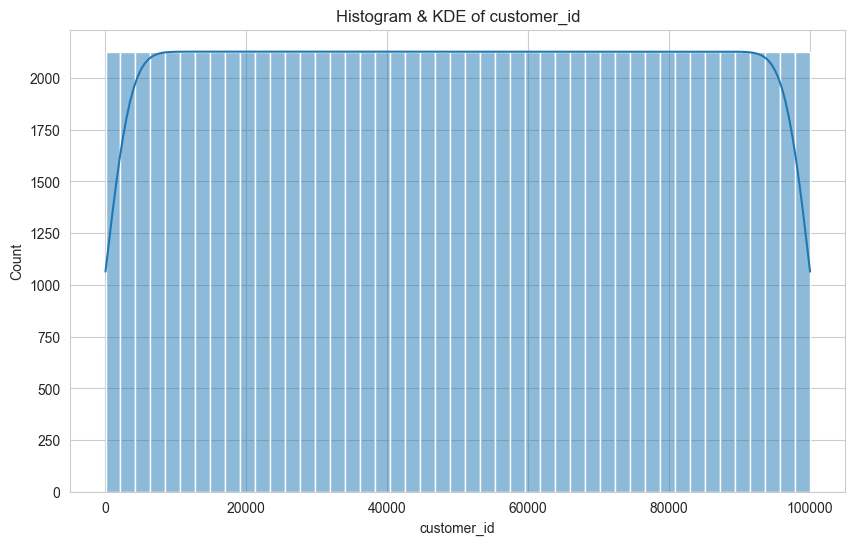

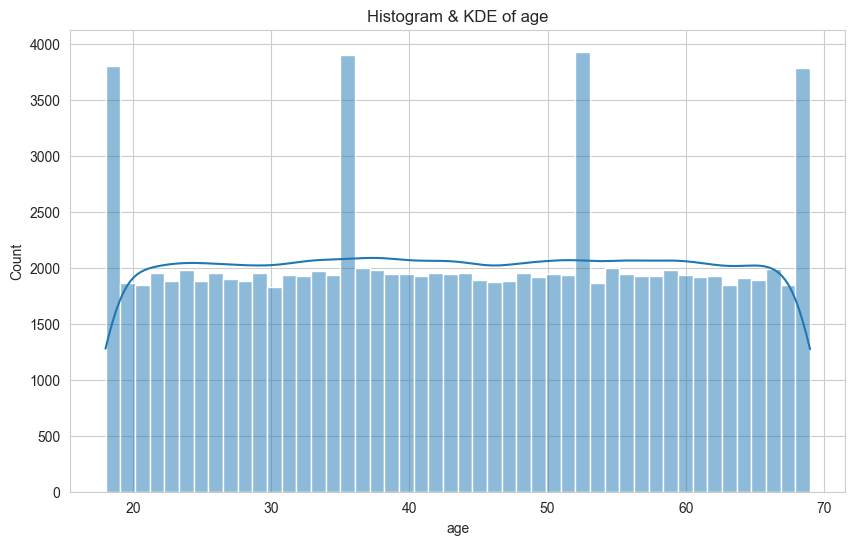

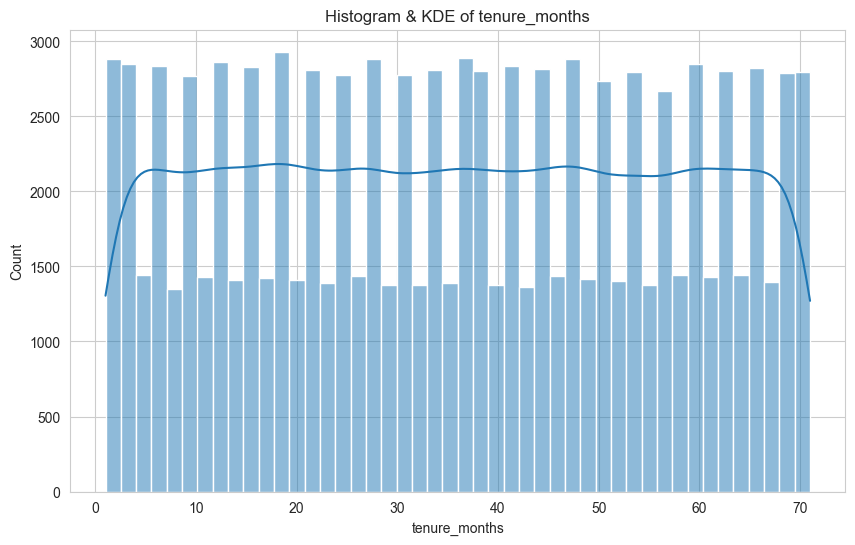

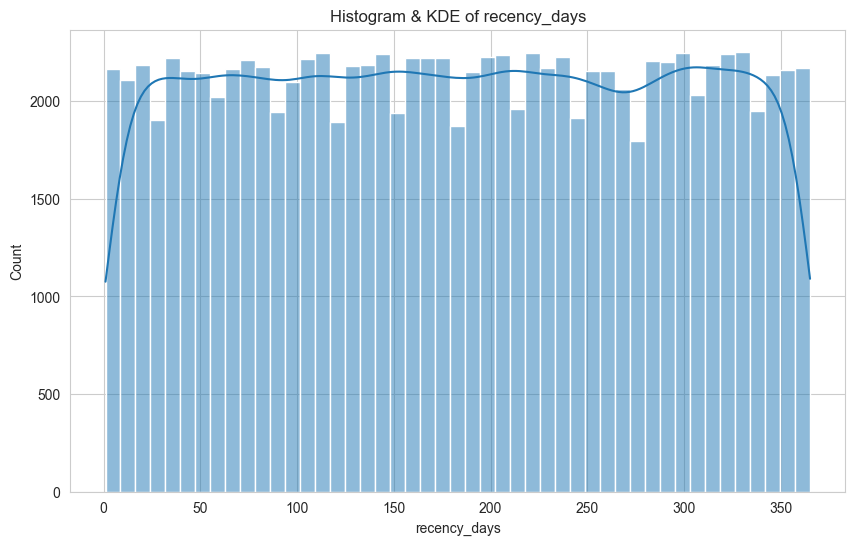

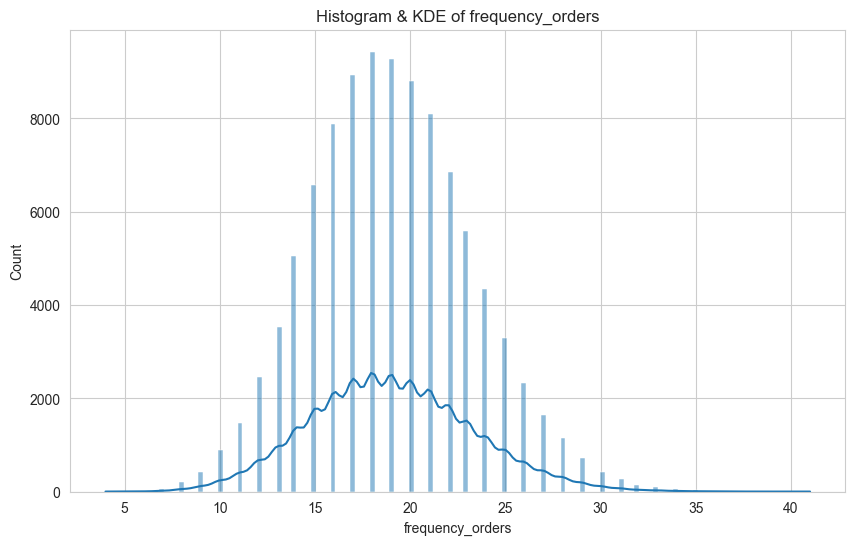

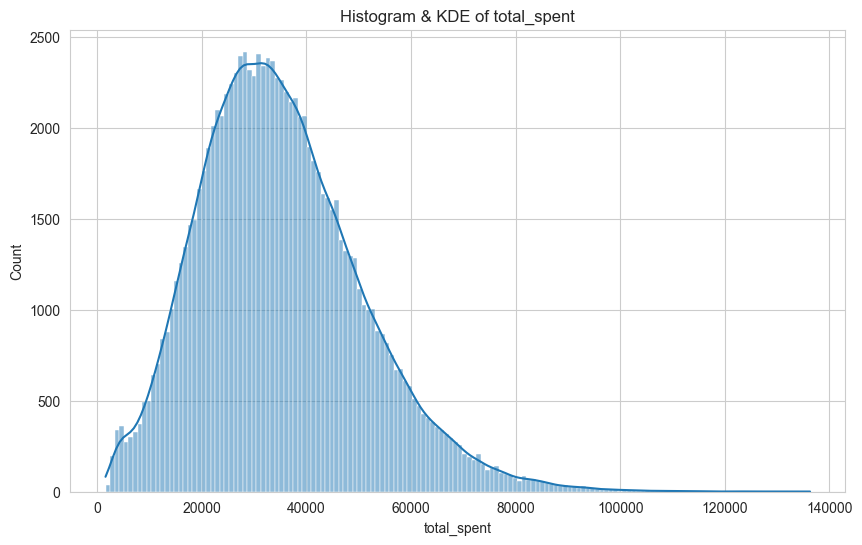

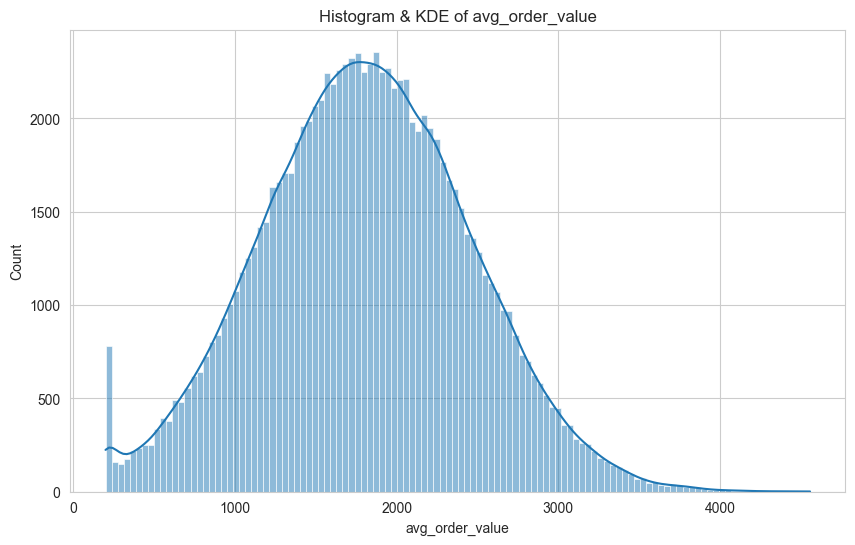

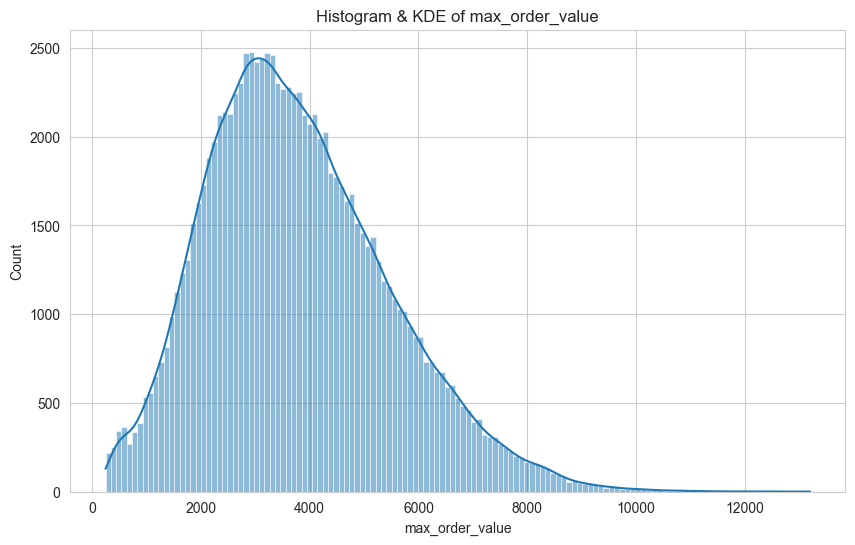

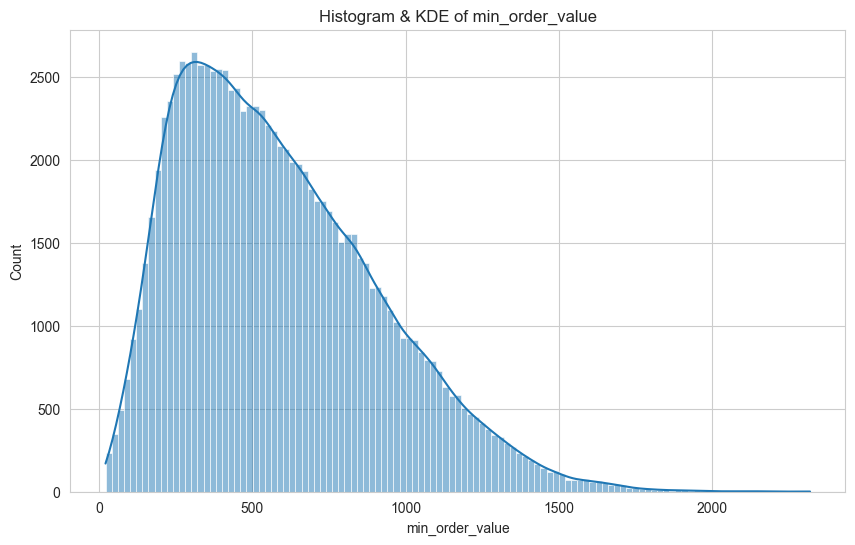

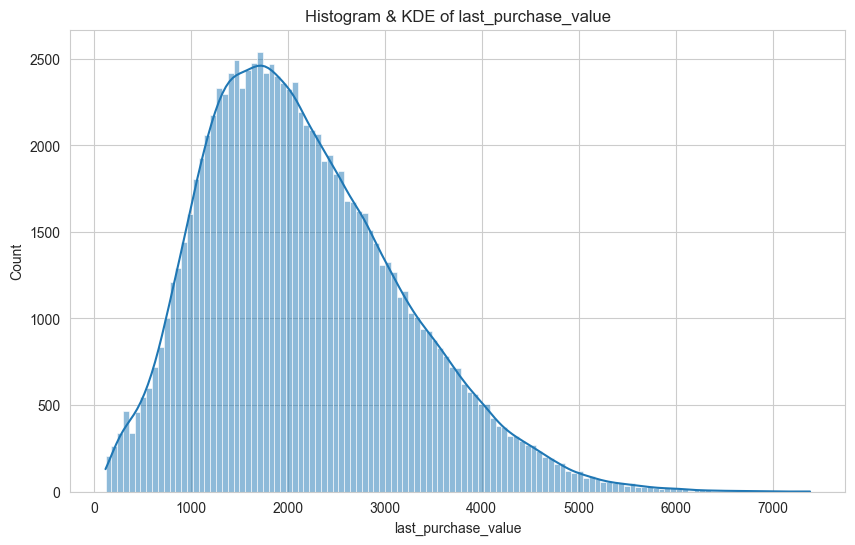

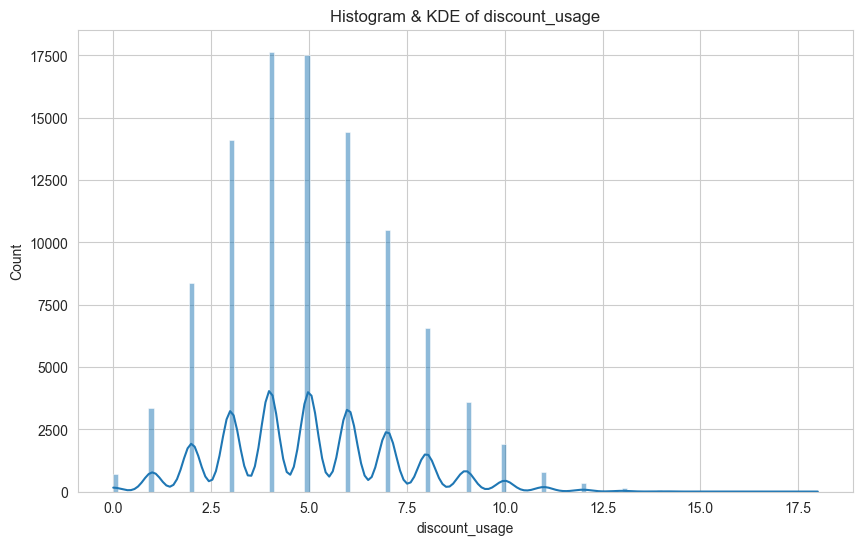

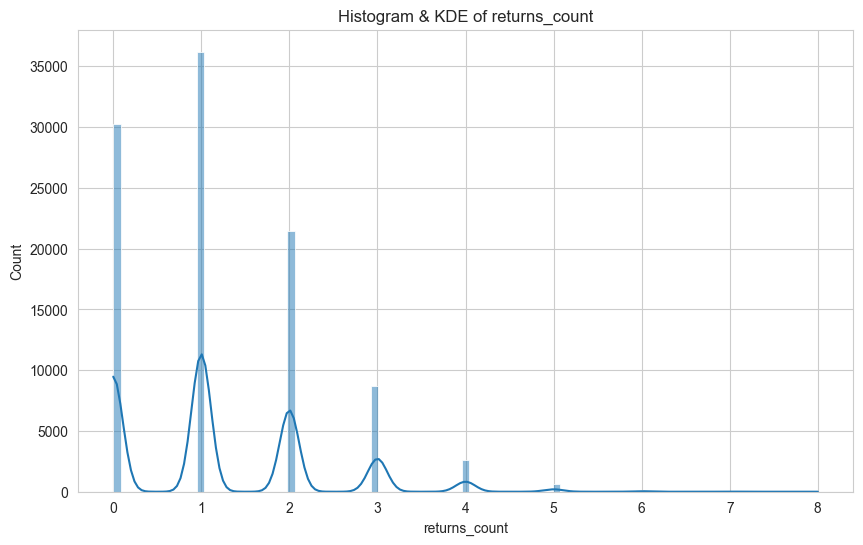

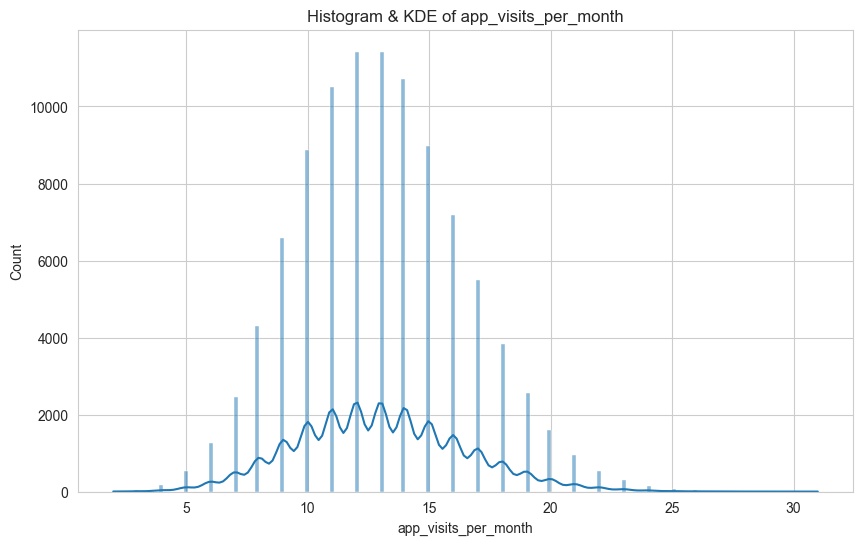

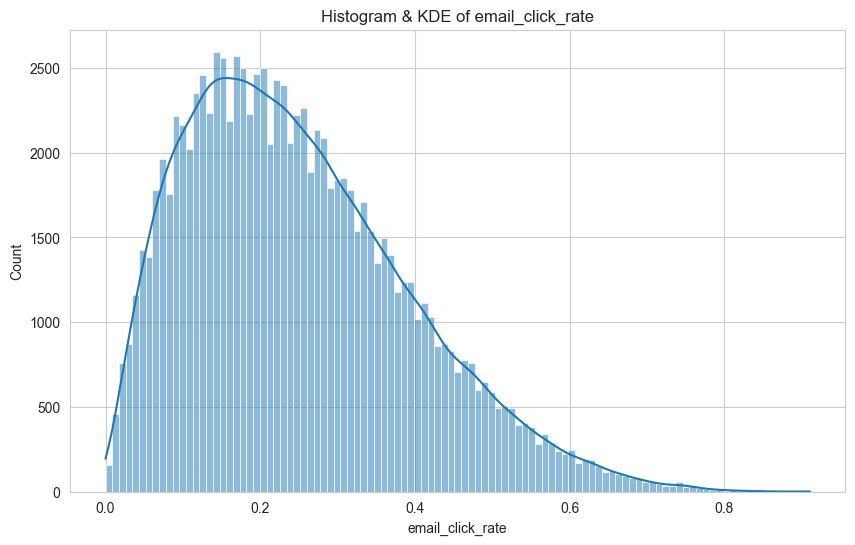

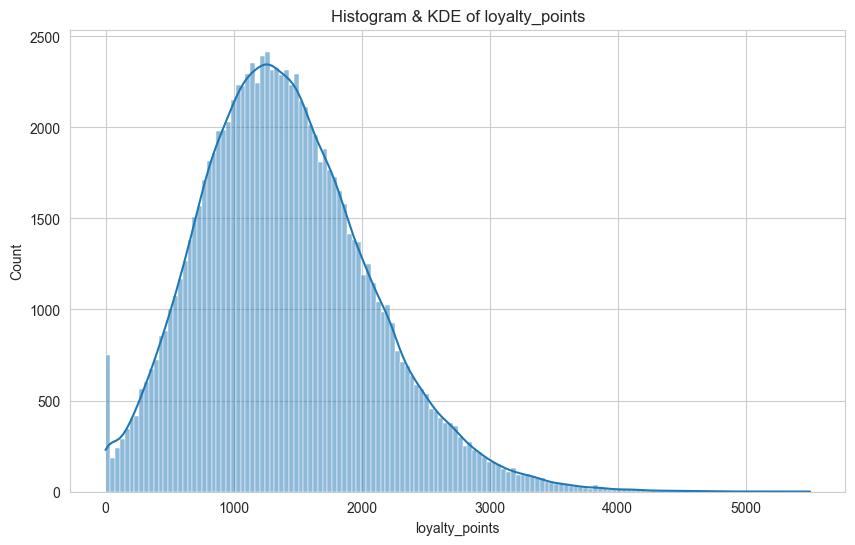

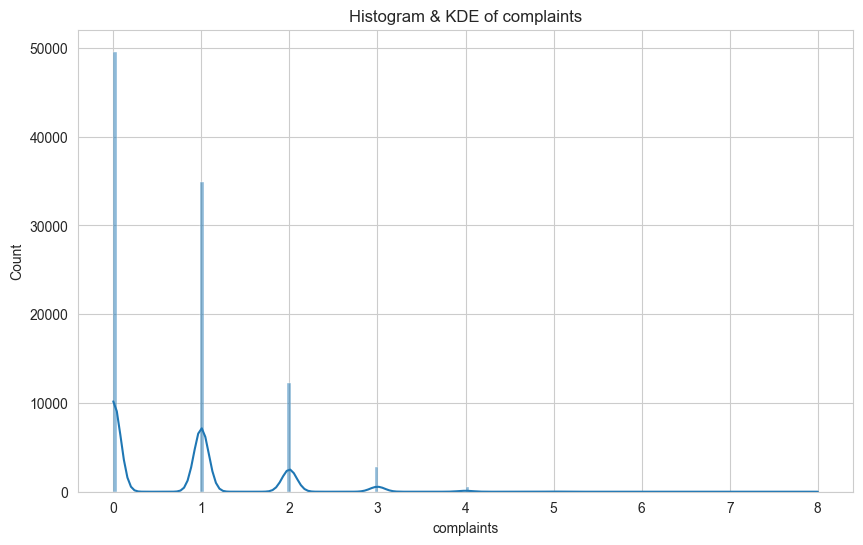

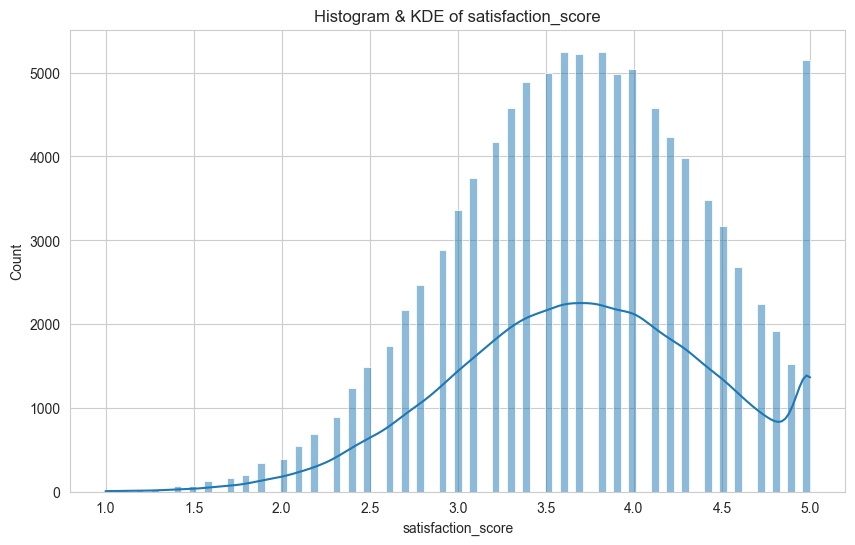

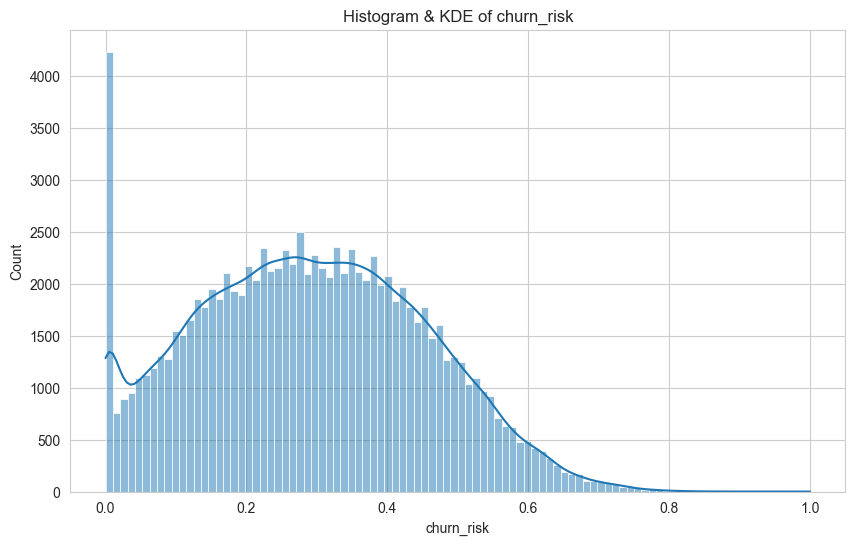

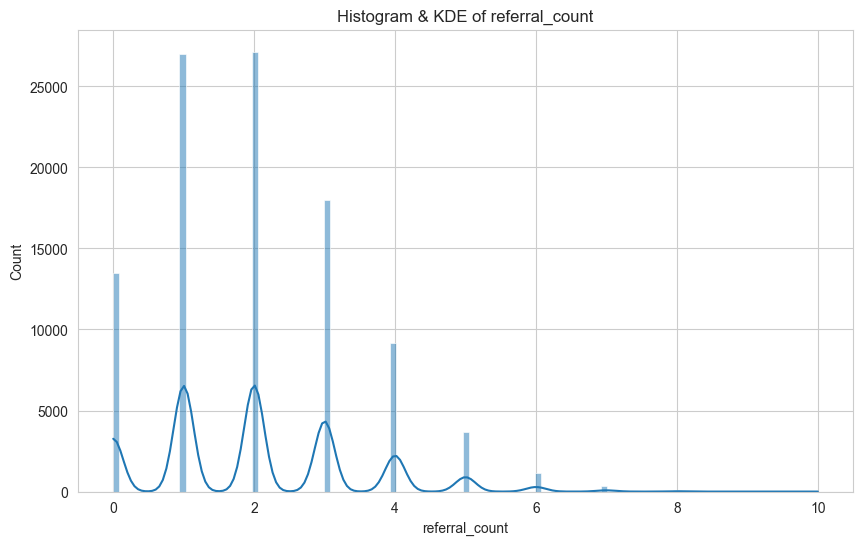

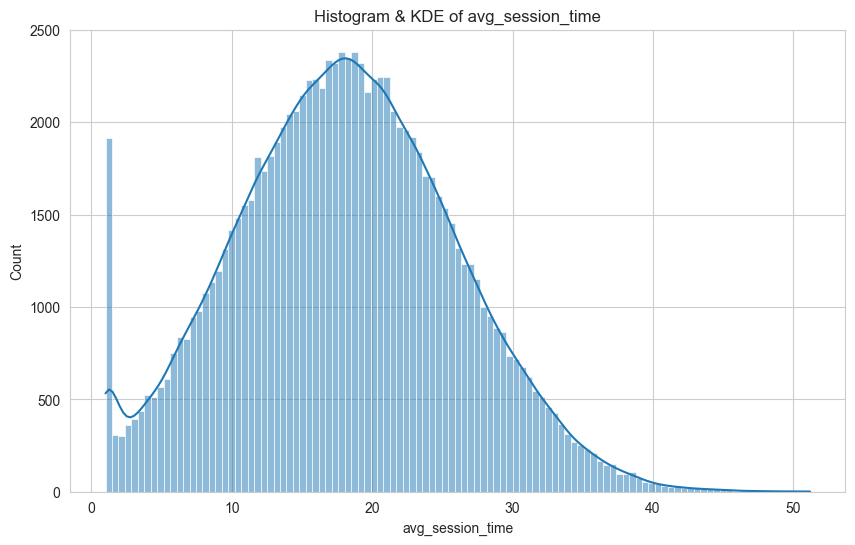

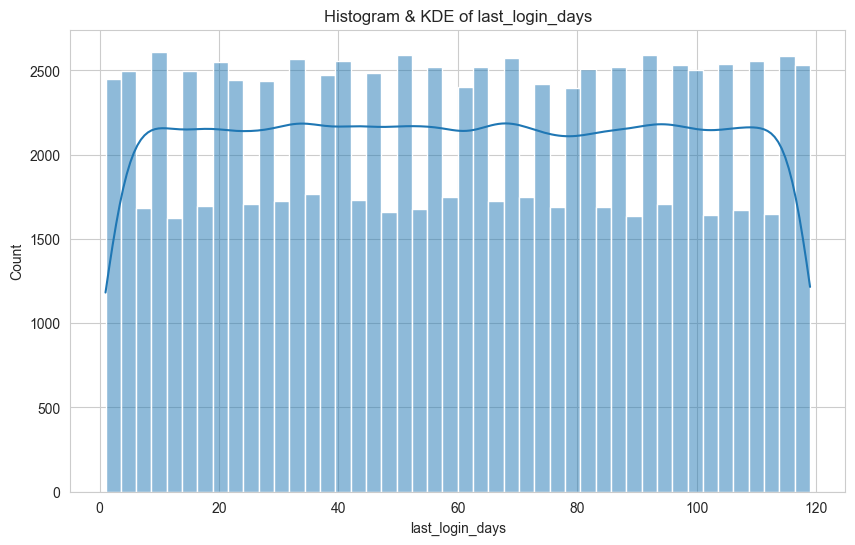

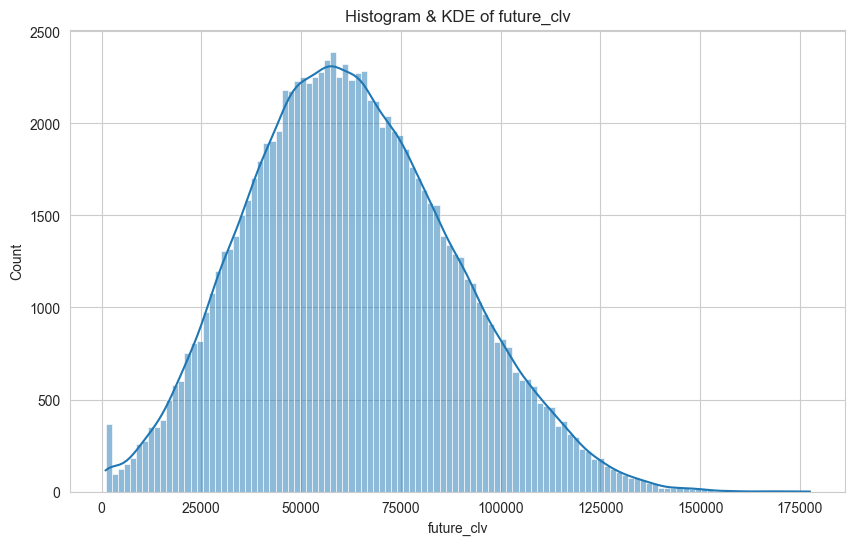

In [36]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

for col in numeric_col:
    plt.figure()
    sns.histplot(dataset[col], kde=True)
    plt.title(f"Histogram & KDE of {col}")
    plt.show()

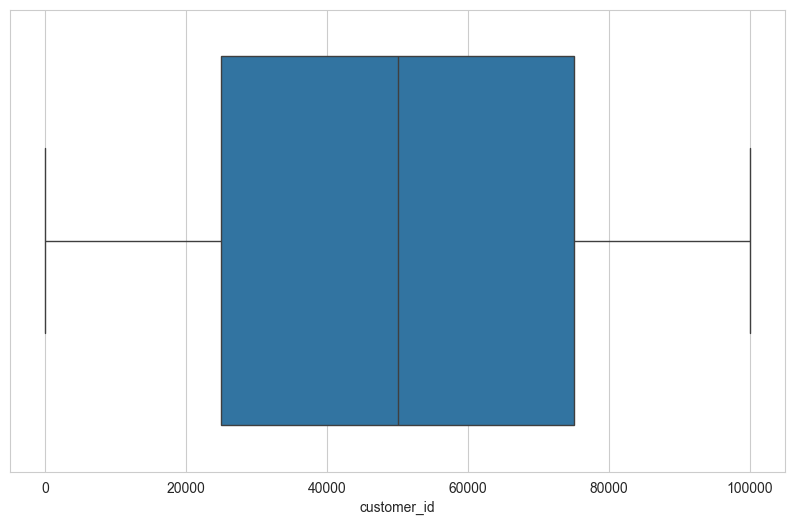

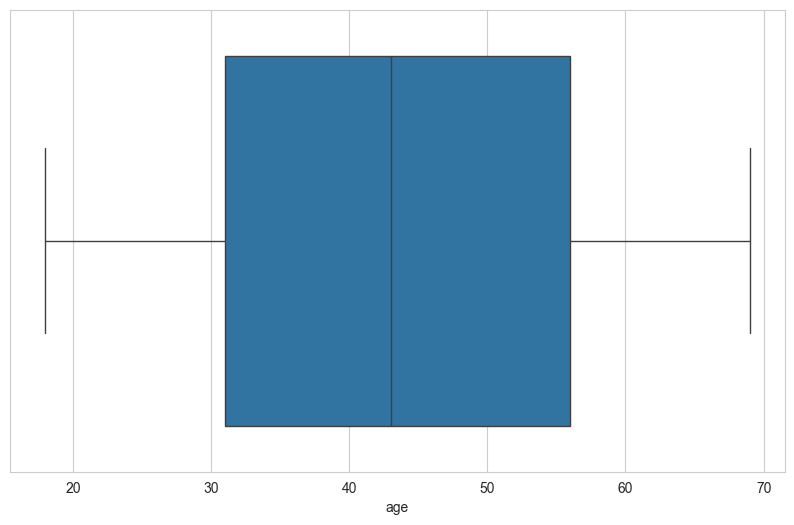

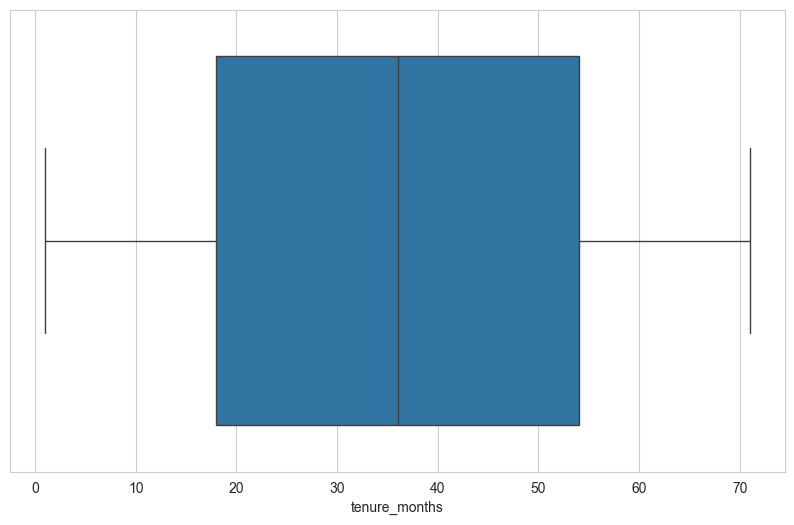

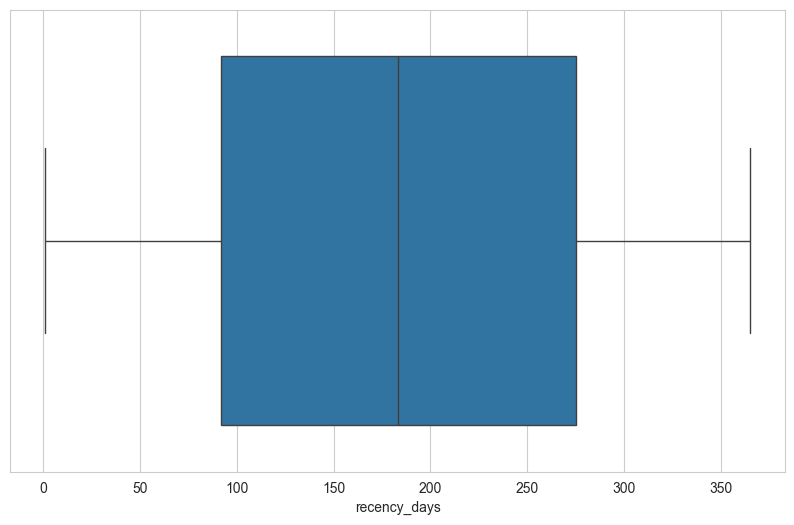

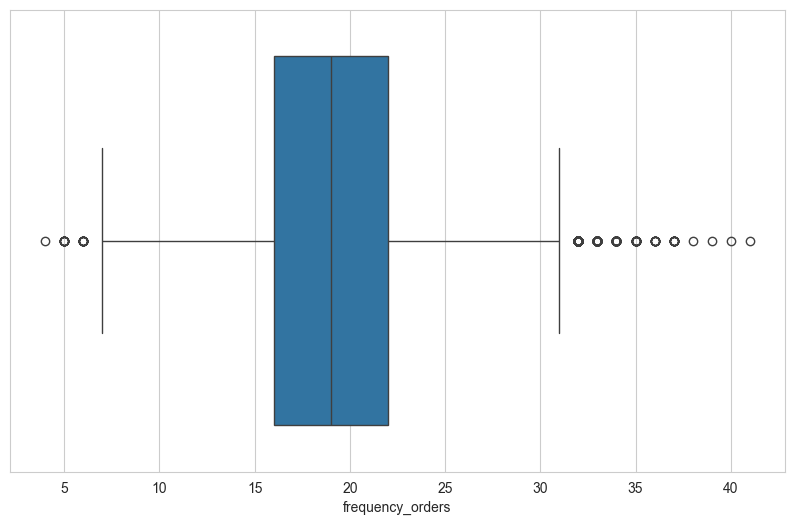

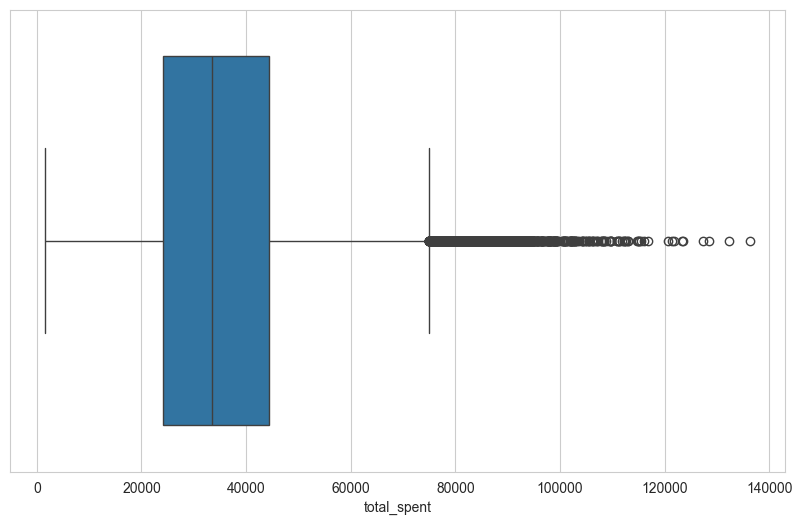

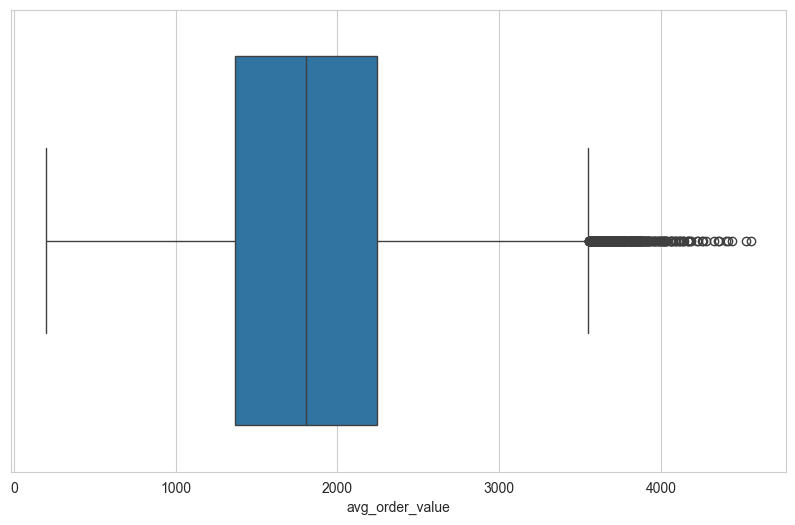

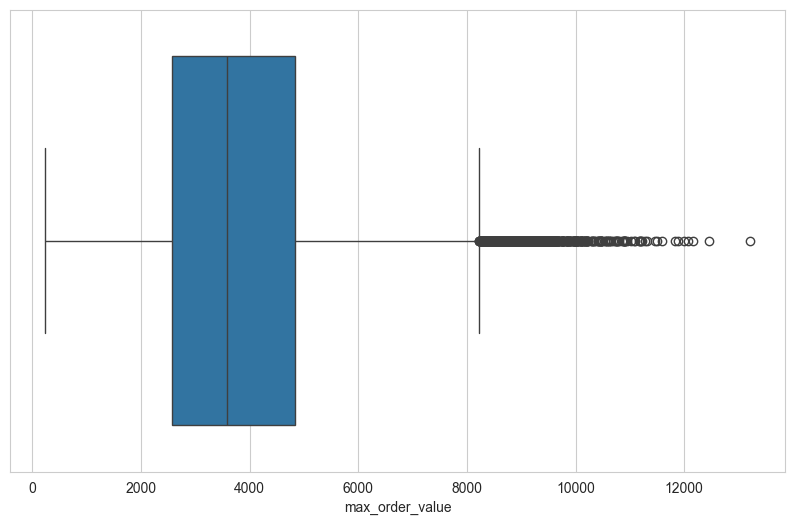

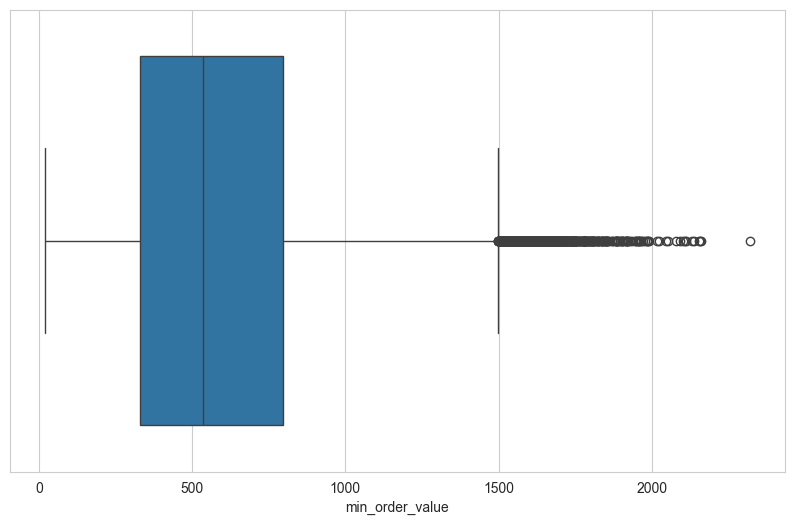

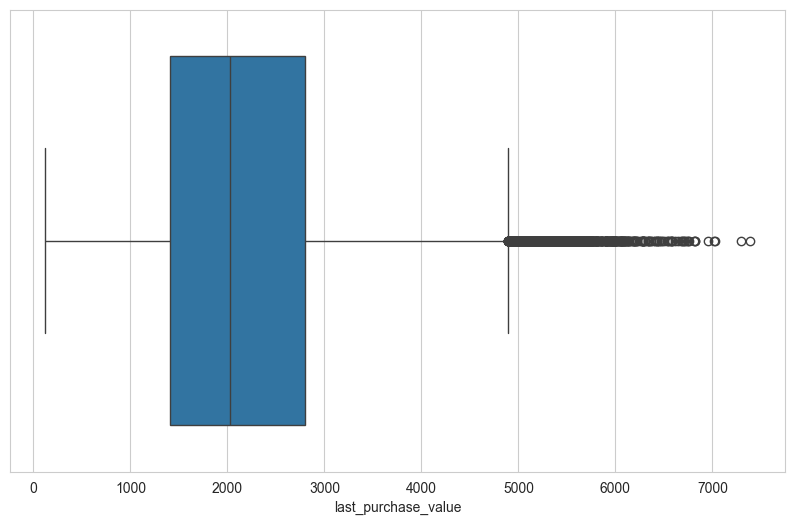

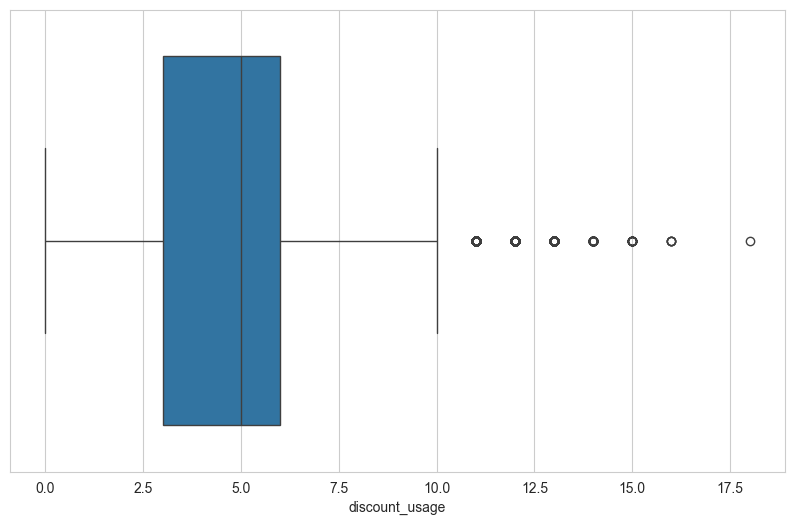

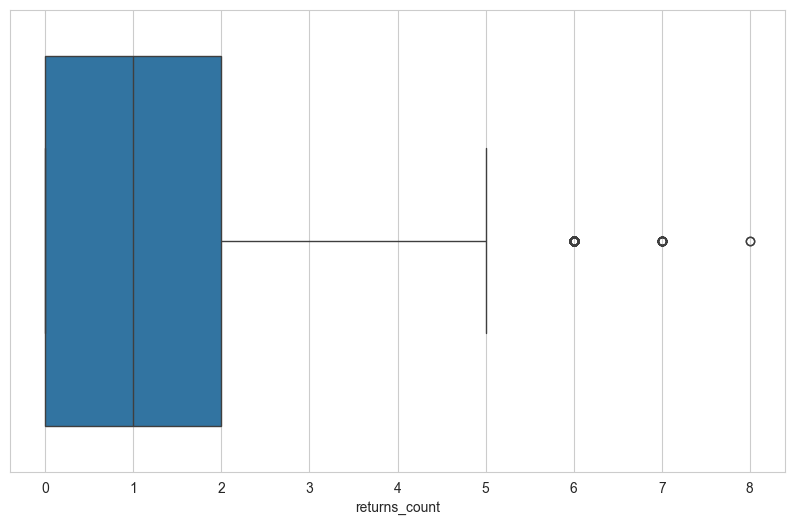

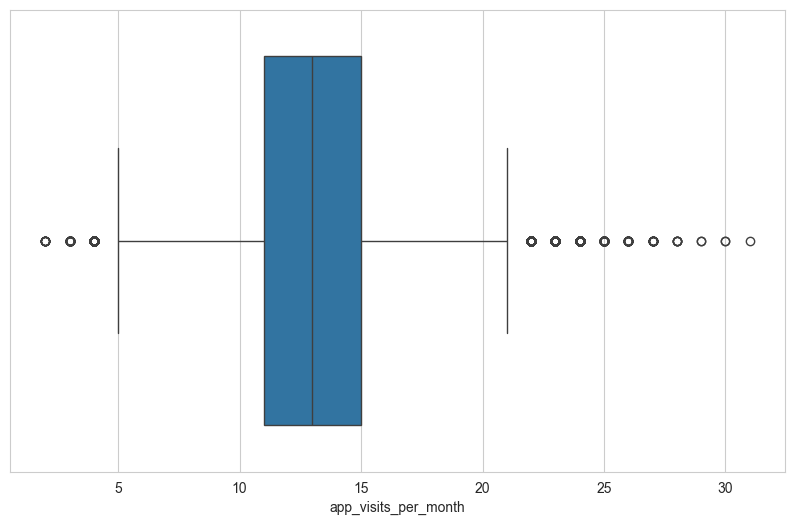

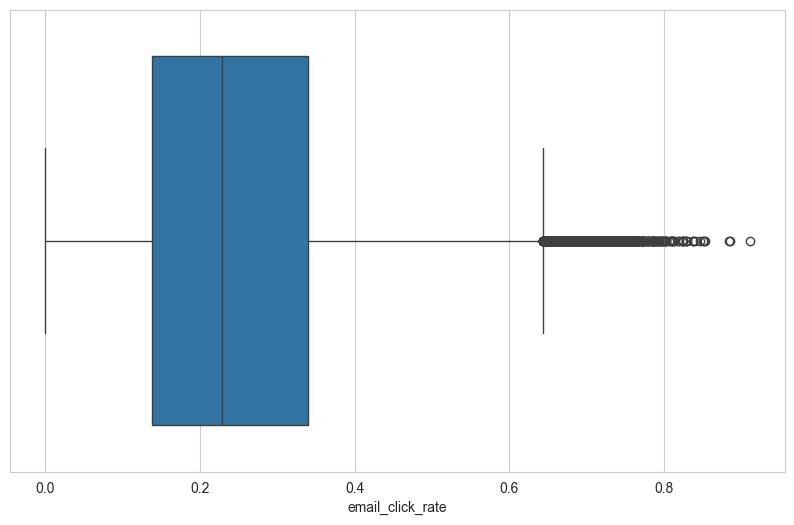

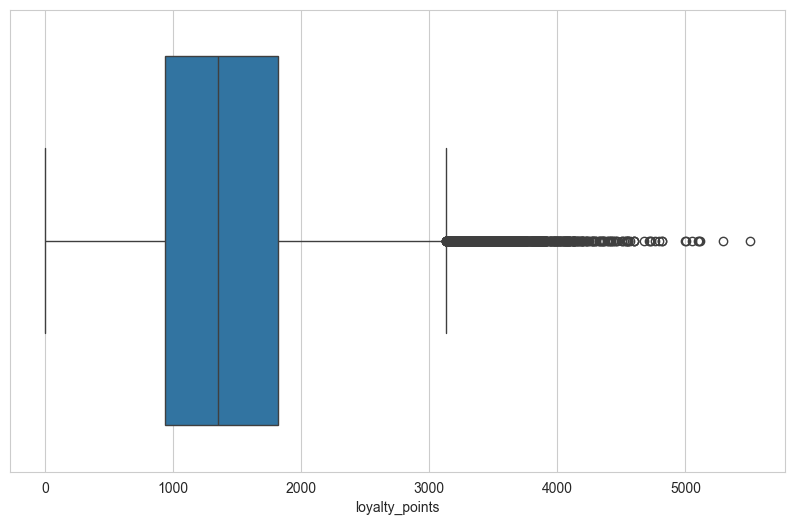

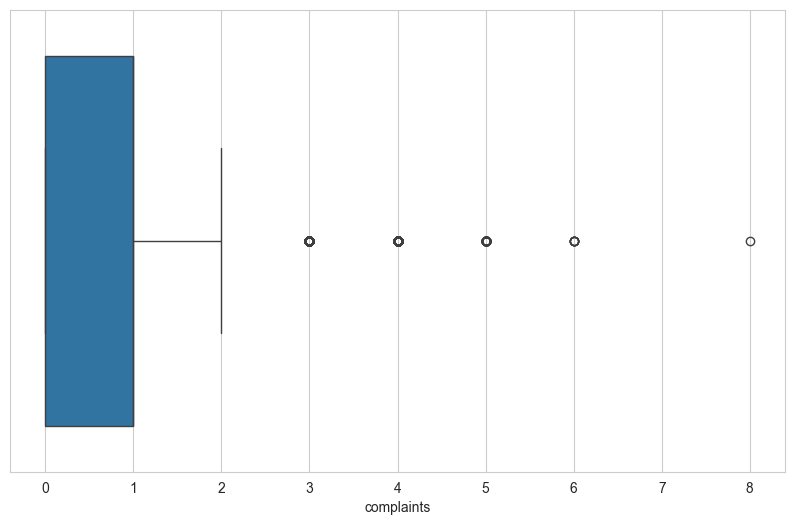

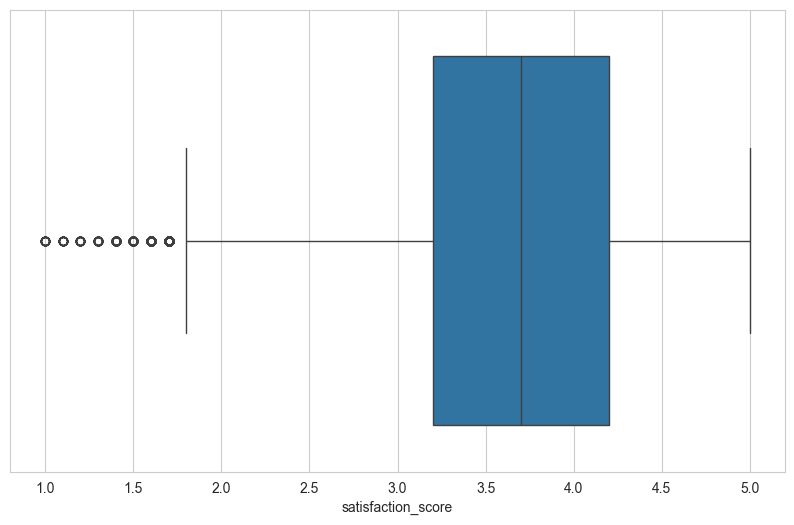

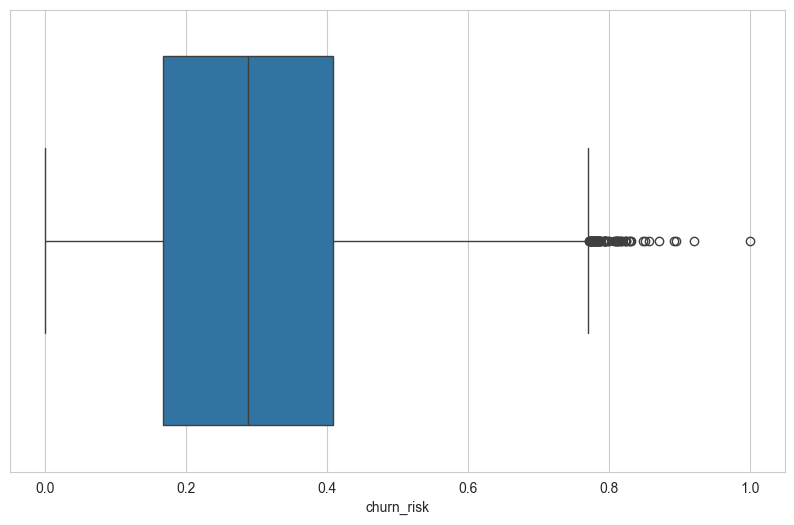

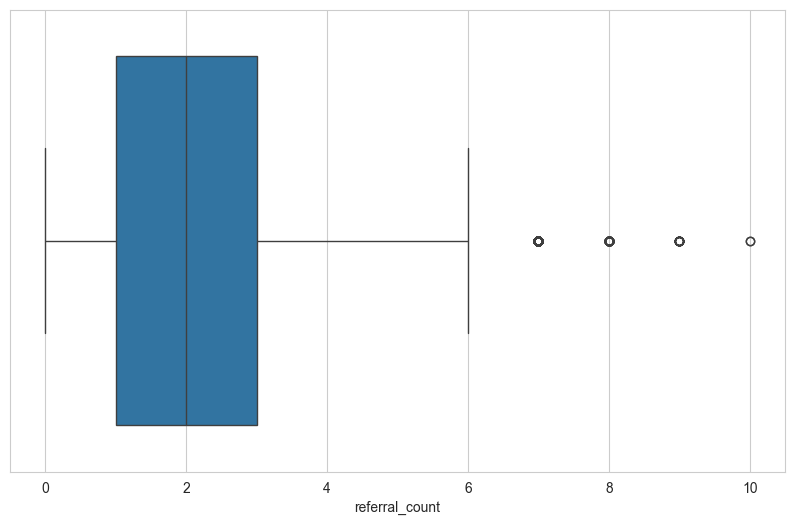

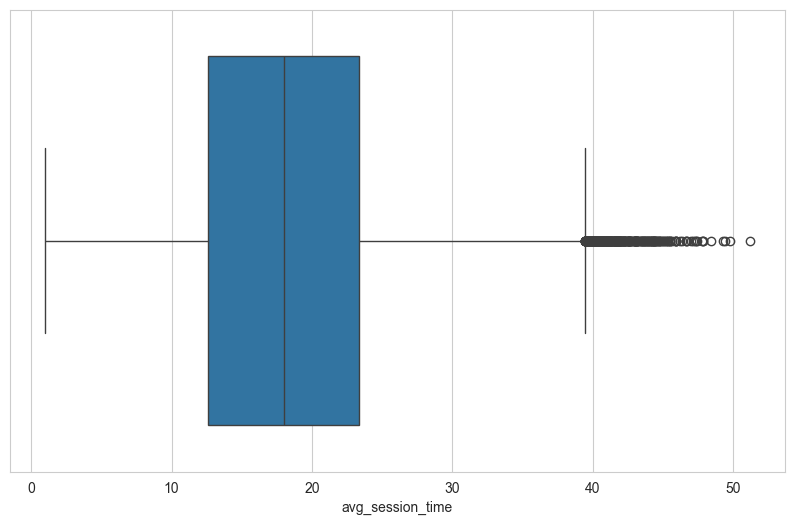

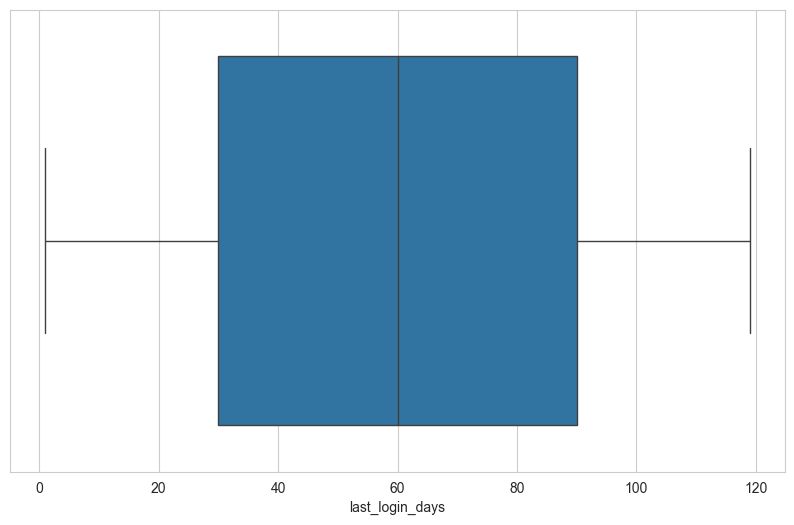

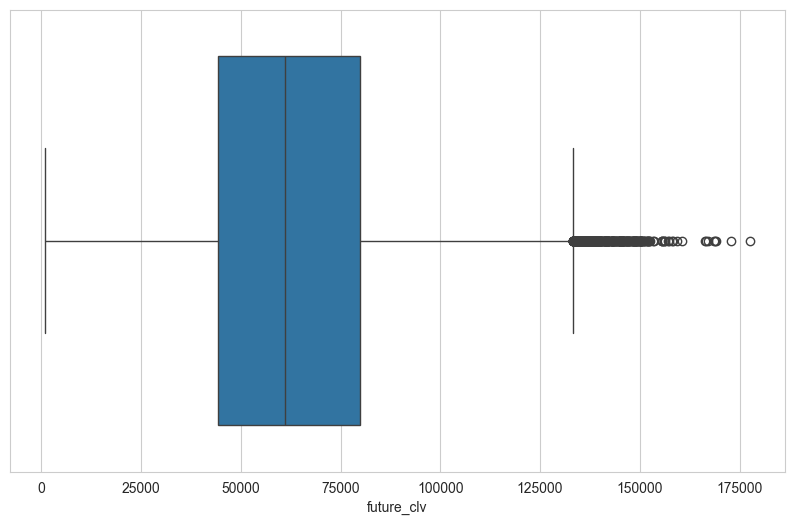

In [37]:
for col in numeric_col:
    plt.figure()
    sns.boxplot(x=dataset[col])
    plt.show()

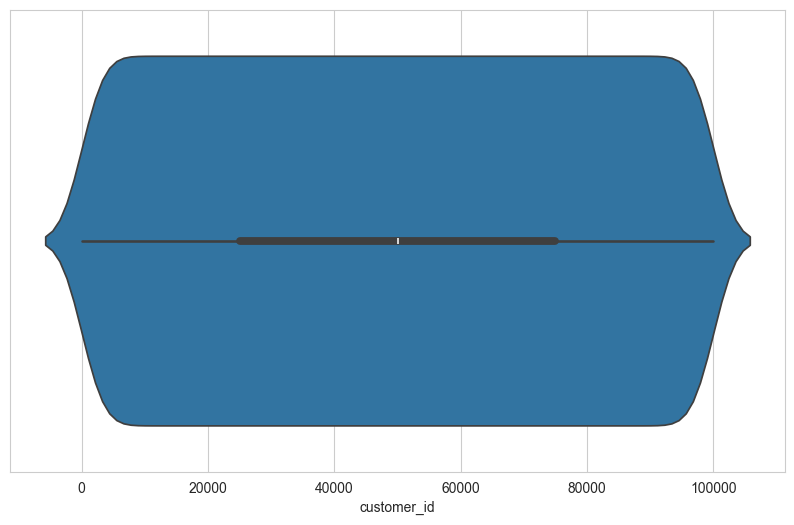

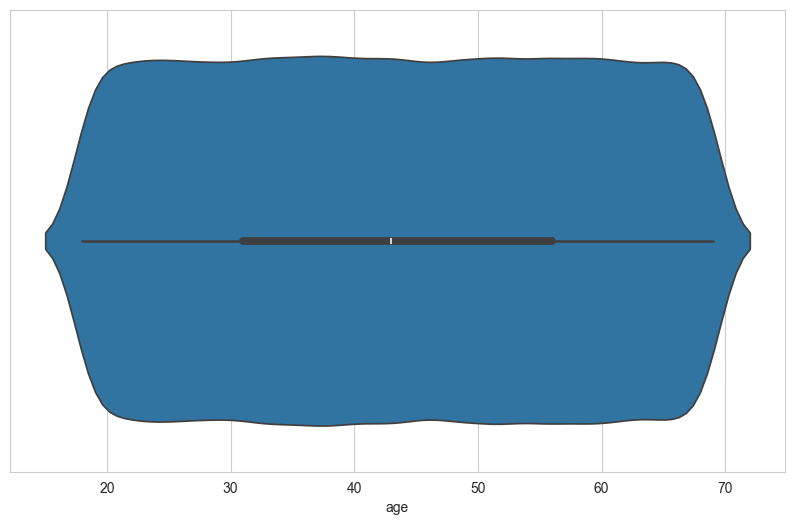

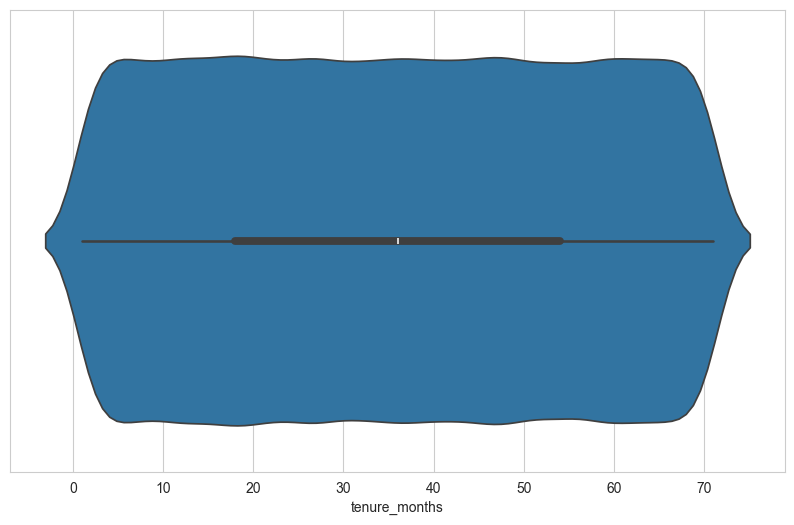

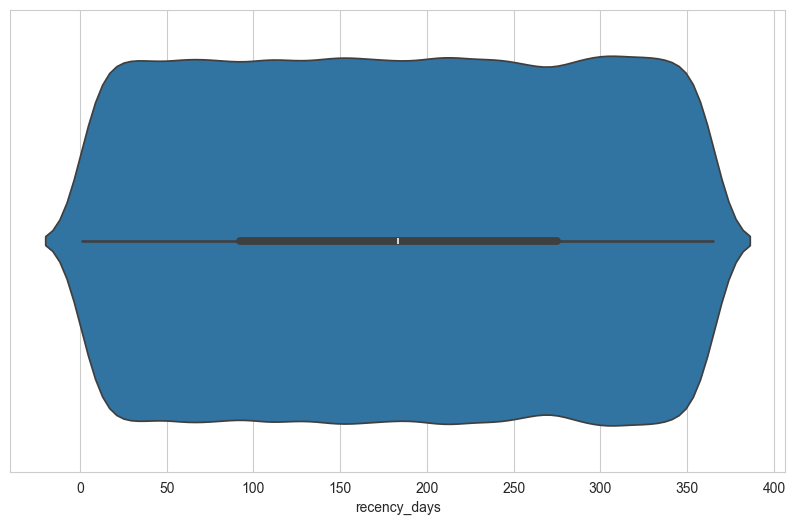

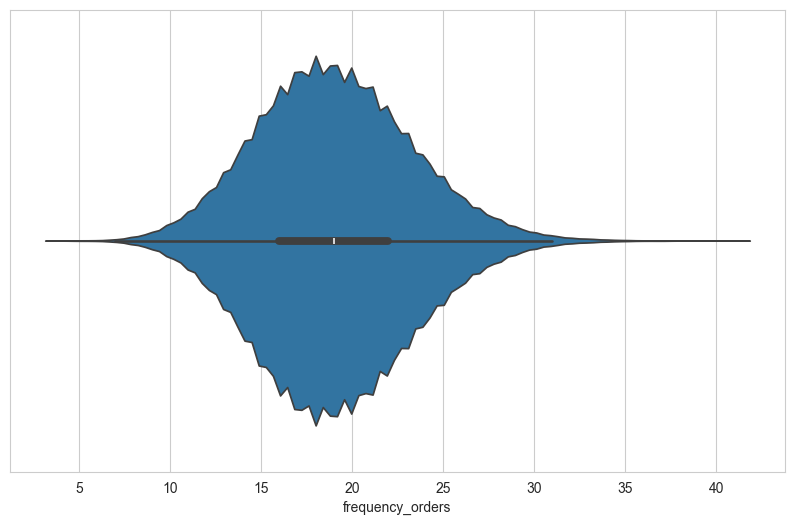

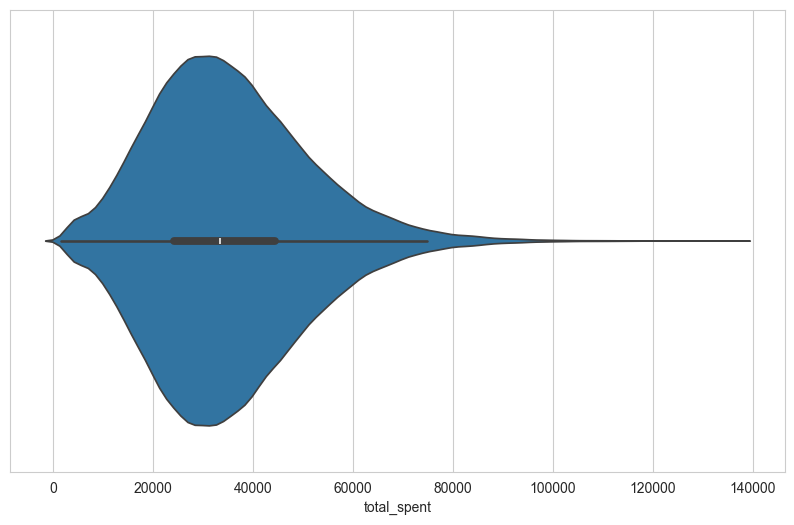

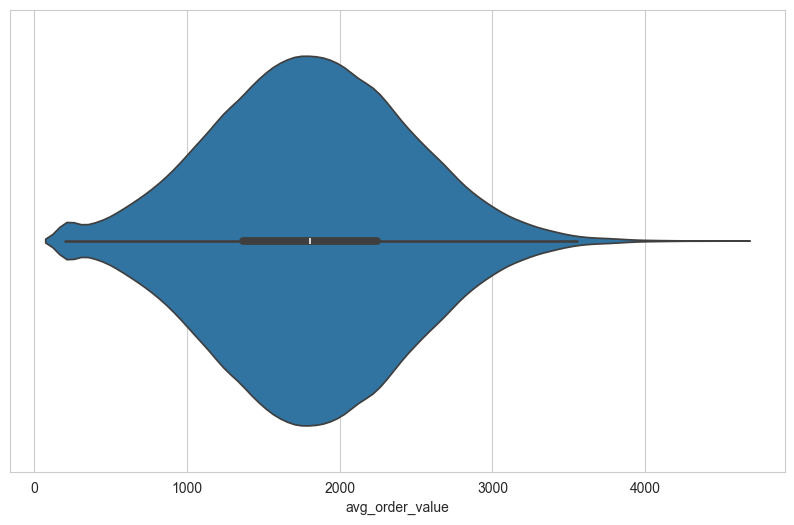

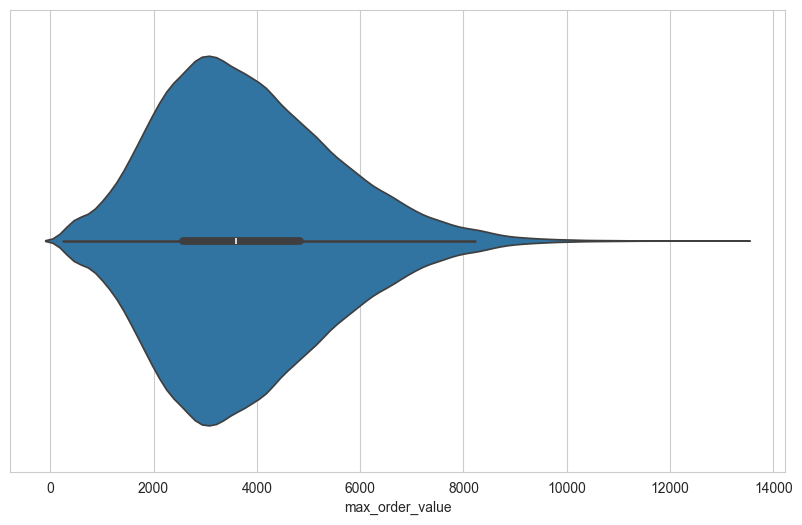

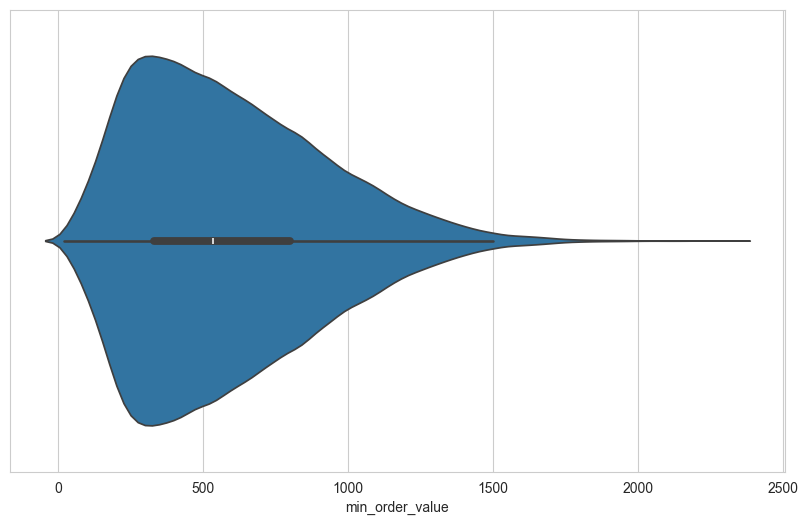

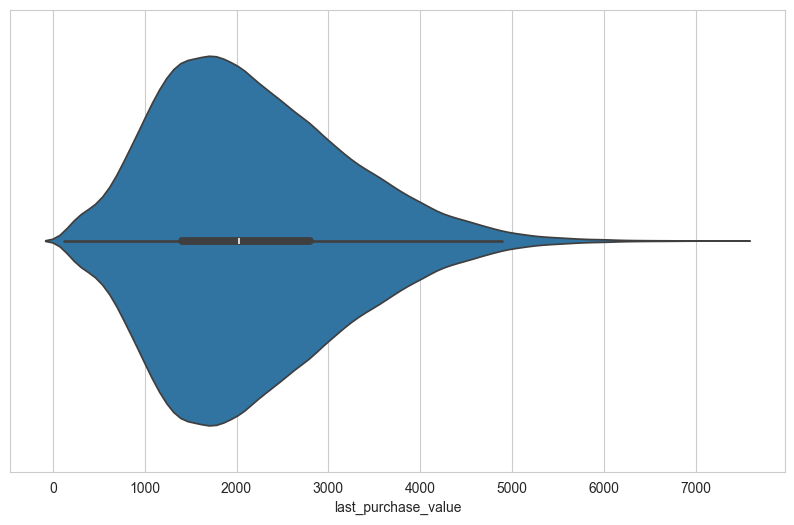

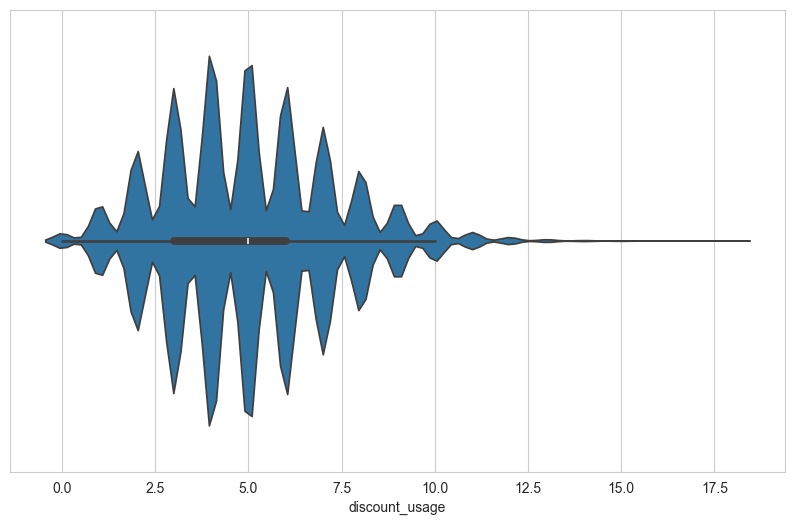

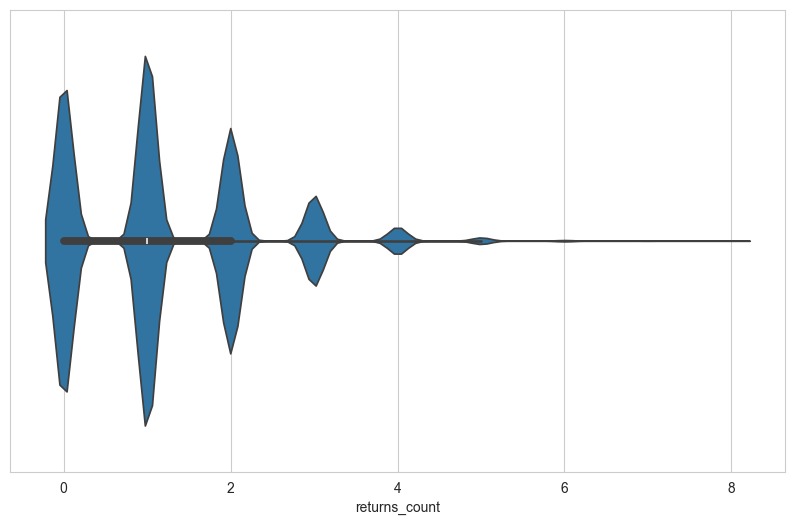

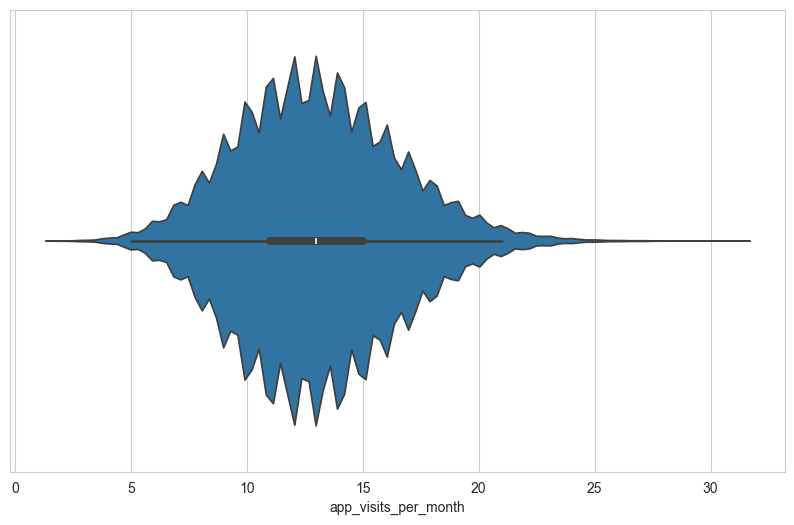

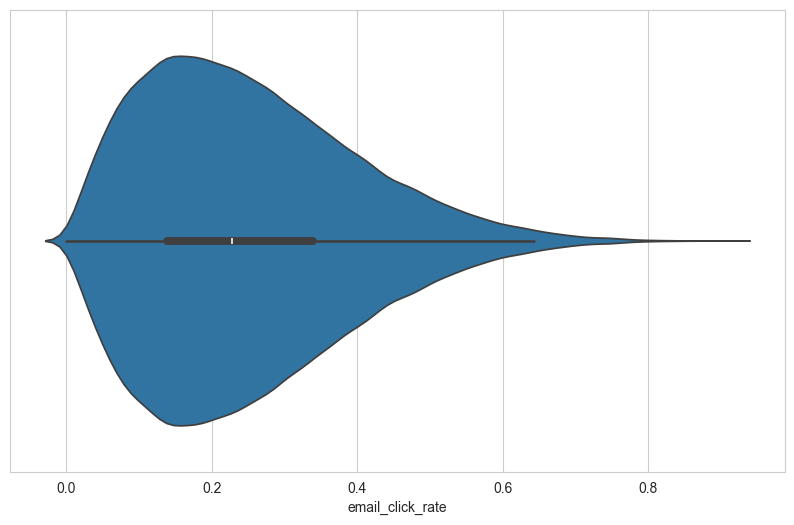

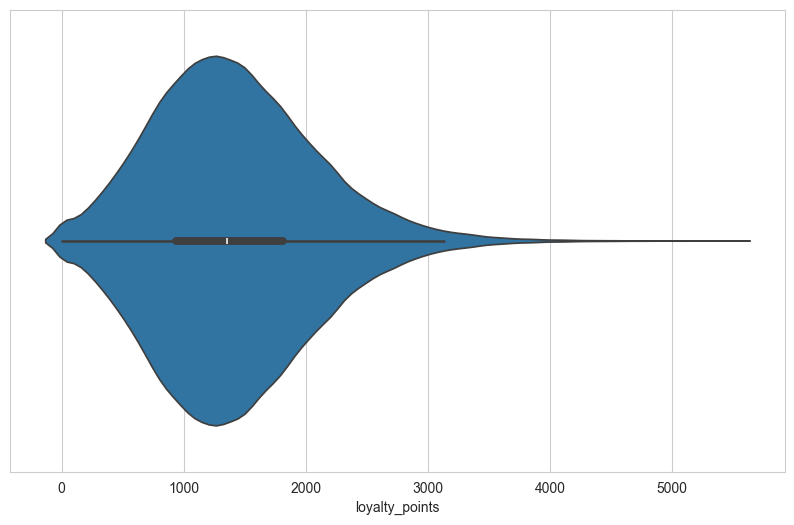

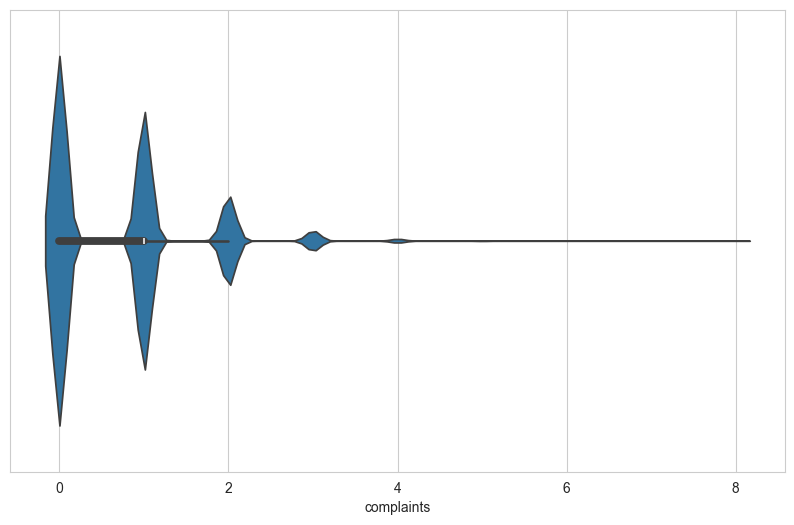

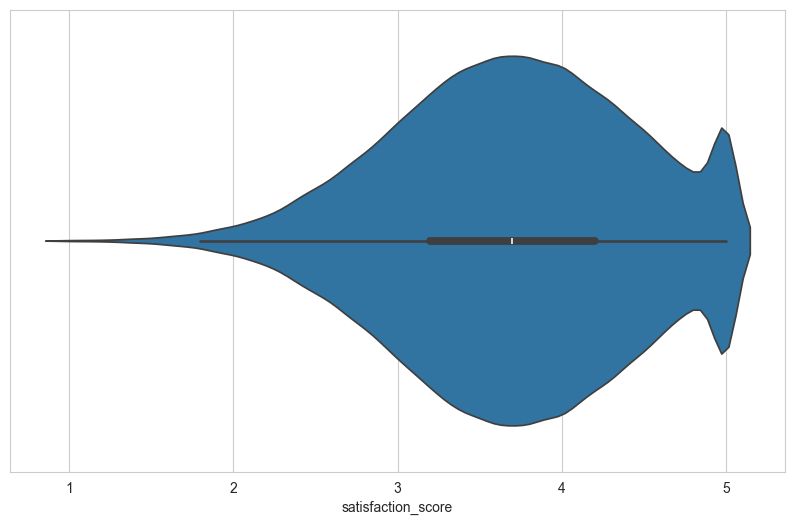

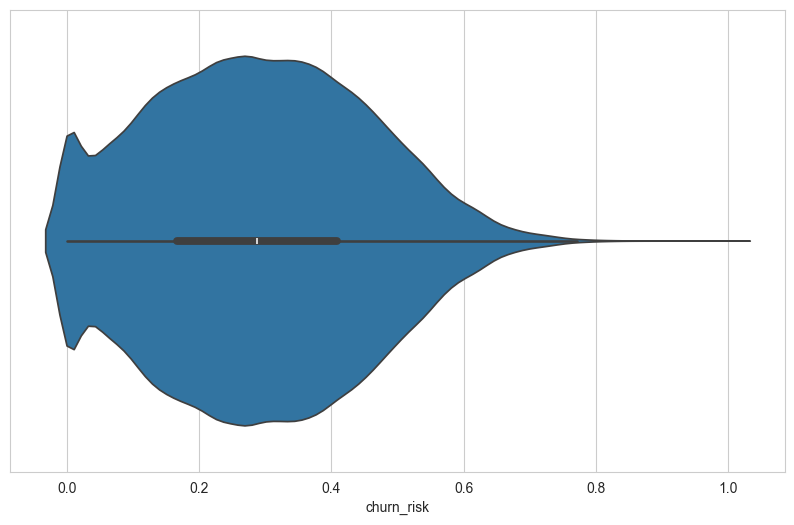

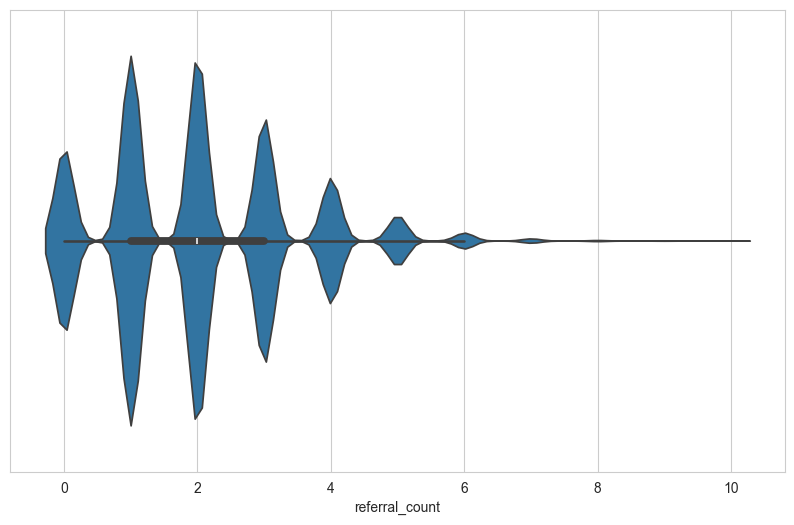

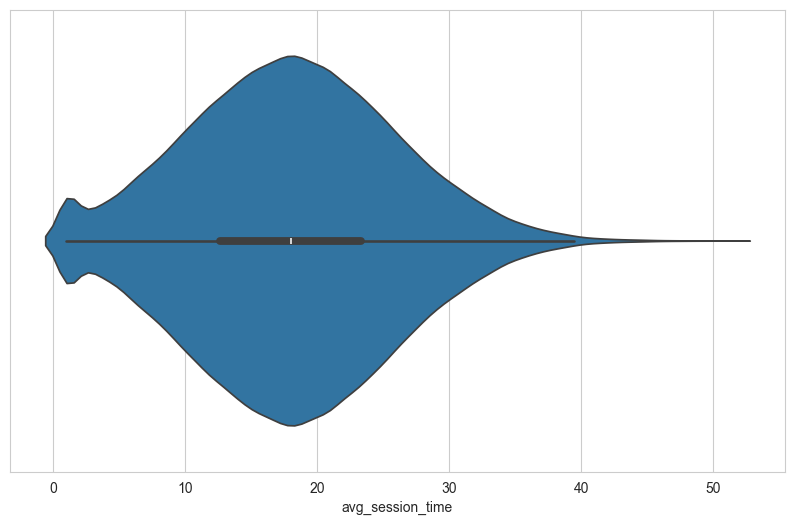

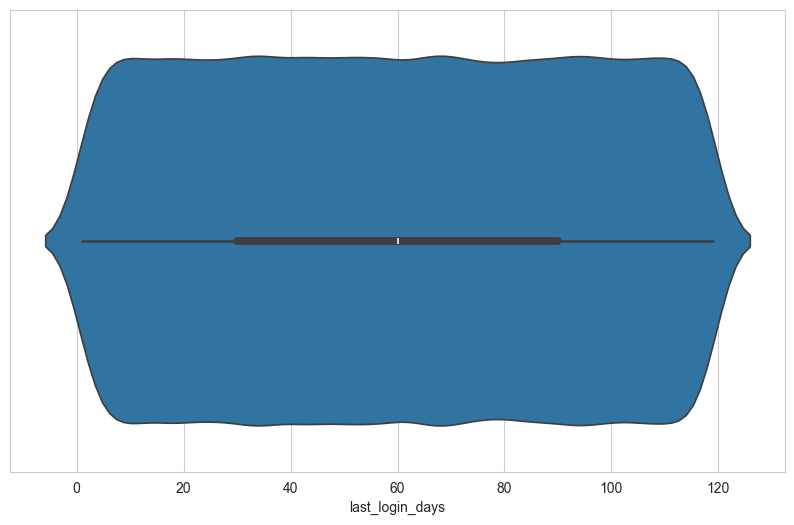

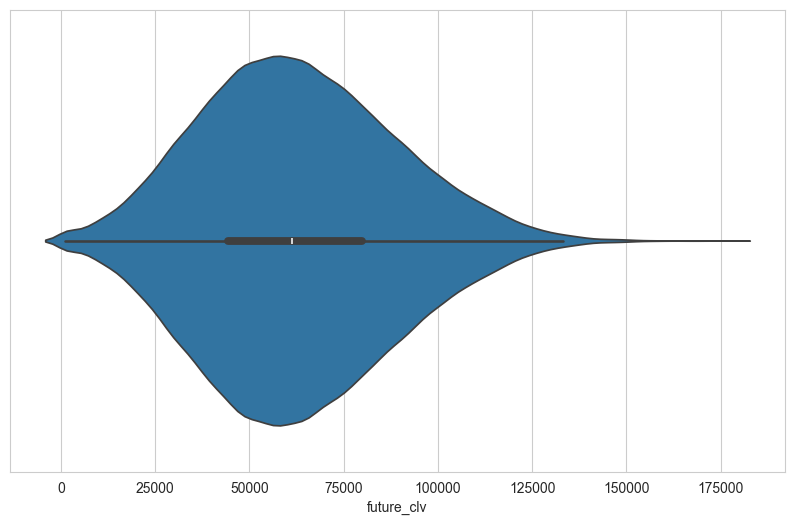

In [38]:
for col in numeric_col:
    plt.figure()
    sns.violinplot(x=dataset[col])
    plt.show()